In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

df = pd.read_csv(r'C:\Users\Gleb\Desktop\Итмо\Основы Питона\fix_data.csv').sort_values(by = 'Loan_ID')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


**Поиск выбросов (IQR)**

In [2]:
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers_iqr_income = find_outliers_iqr(df['ApplicantIncome'])
outliers_iqr_loan = find_outliers_iqr(df['LoanAmount'])

len(outliers_iqr_income), len(outliers_iqr_loan)

(50, 41)

**Поиск выбросов (STD)**

In [3]:
def find_outliers_std(series):
    mean = series.mean()
    std = series.std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    return series[(series < lower) | (series > upper)]

outliers_std_income = find_outliers_std(df['ApplicantIncome'])
outliers_std_loan = find_outliers_std(df['LoanAmount'])

len(outliers_std_income), len(outliers_std_loan)

(8, 15)

**Сравнение выбросов**

In [4]:
std_idx_income = set(outliers_std_income.index)
iqr_idx_income = set(outliers_iqr_income.index)

iqr_idx_loan = set(outliers_iqr_loan.index)
std_idx_loan = set(outliers_std_loan.index)

print("ApplicantIncome:")
print("Пересечение:", len(iqr_idx_income & std_idx_income))
print("Только IQR:", len(iqr_idx_income - std_idx_income))
print("Только STD:", len(std_idx_income - iqr_idx_income))

print("\nLoanAmount:")
print("Пересечение:", len(iqr_idx_loan & std_idx_loan))
print("Только IQR:", len(iqr_idx_loan - std_idx_loan))
print("Только STD:", len(std_idx_loan - iqr_idx_loan))

ApplicantIncome:
Пересечение: 8
Только IQR: 42
Только STD: 0

LoanAmount:
Пересечение: 15
Только IQR: 26
Только STD: 0


- Метод IQR находит больше выбросов, так как он основан на квартилях и чувствителен к асимметрии распределения

- Метод стандартного отклонения (3σ) выявляет только крайние значения, так как ориентируется на среднее и стандартное отклонение

- Различия возникают из-за того, что распределение данных может быть несимметричным

**Визуализация**

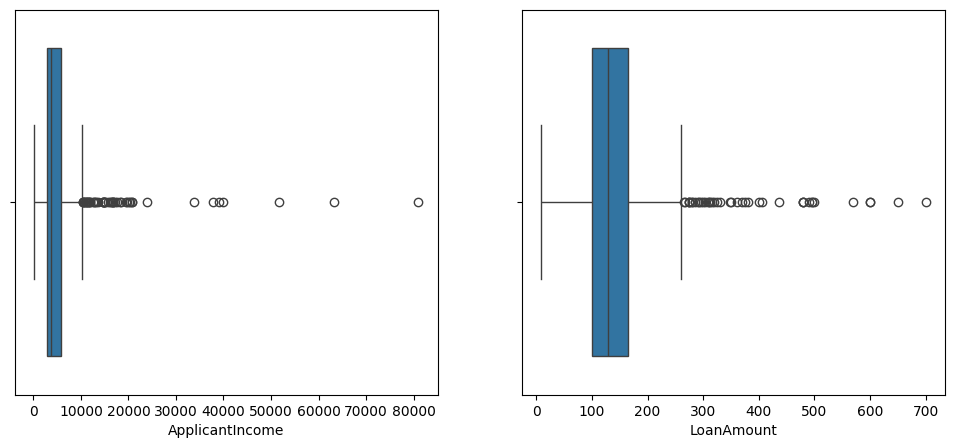

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['ApplicantIncome'])

plt.subplot(1,2,2)
sns.boxplot(x=df['LoanAmount'])

plt.show()

- Выбросы решено не удалять, поскольку они могут отражать реальные значения, например клиентов с высокими доходами или крупными кредитами

- Удаление таких наблюдений может привести к потере важной информации и искажению анализа

- Бинарные признаки (где 2 значения) переводим в 0 и 1

- Признаки с несколькими категориями разбиваем на отдельные столбцы, чтобы не появлялся ложный порядок между категориями

**Применение кодирования**

In [6]:
df = df.drop('Loan_ID', axis=1, errors='ignore')

df_encoded = pd.get_dummies(df, drop_first=True)

bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

**Проверка результата**

In [7]:
df_encoded.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1
1,4583,1508.0,128.0,360.0,1.0,1,1,1,0,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,1,0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,1,0,0,1,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1
